In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Libraries imported")


Libraries imported


In [2]:
df = pd.read_csv(r"C:\Users\lohith\Downloads\train.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Column data types:")
print(df.dtypes.value_counts())
print()
print(f"Numeric columns:     {df.select_dtypes(include=np.number).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include='object').shape[1]}")


Column data types:
object     43
int64      35
float64     3
Name: count, dtype: int64

Numeric columns:     38
Categorical columns: 43


In [4]:
print("Target Variable: SalePrice")
print(df['SalePrice'].describe())


Target Variable: SalePrice
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(f"Columns with missing values: {len(missing_table)}")
missing_table


Columns with missing values: 19


,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


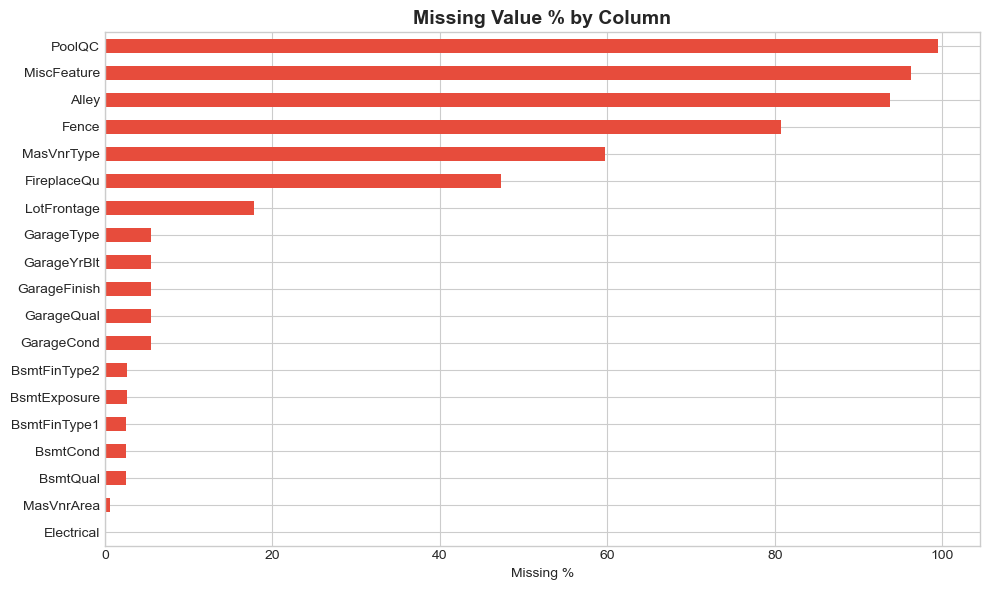

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_table['Missing %'].plot(kind='barh', color='#e74c3c', ax=ax)
ax.set_title('Missing Value % by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing %')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('missing_values.png', dpi=120, bbox_inches='tight')
plt.show()


In [7]:
df_clean = df.copy()

# Columns where NaN genuinely means "feature absent" -> fill with 'None'
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtExposure','BsmtFinType2','BsmtQual','BsmtCond','BsmtFinType1',
             'MasVnrType']
for col in none_cols:
    df_clean[col] = df_clean[col].fillna('None')

df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(0)
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'] \
                                    .transform(lambda x: x.fillna(x.median()))
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

print(f"Missing values before: {df.isnull().sum().sum()}")
print(f"Missing values after:  {df_clean.isnull().sum().sum()}")


Missing values before: 7829
Missing values after:  0


In [8]:
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le

print(f"Encoded {len(cat_cols)} categorical columns")
print(f"Final dataset shape: {df_clean.shape}")


Encoded 43 categorical columns
Final dataset shape: (1460, 81)


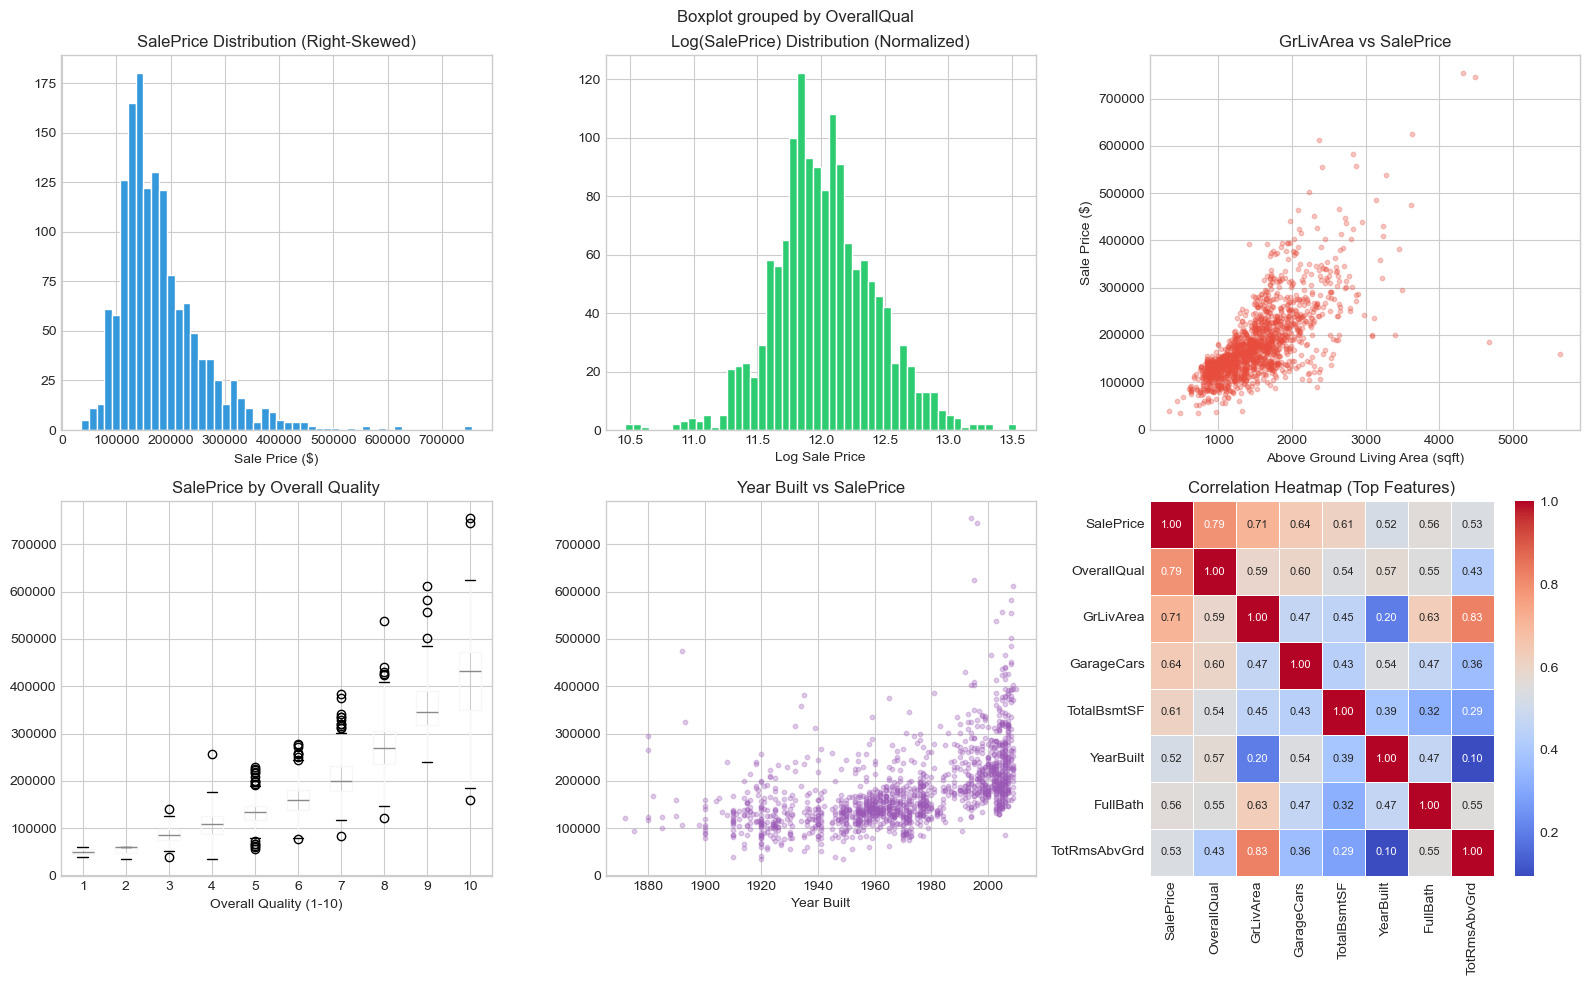

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — House Price Prediction', fontsize=16, fontweight='bold')

axes[0,0].hist(df['SalePrice'], bins=50, color='#3498db', edgecolor='white')
axes[0,0].set_title('SalePrice Distribution (Right-Skewed)')
axes[0,0].set_xlabel('Sale Price ($)')

axes[0,1].hist(np.log1p(df['SalePrice']), bins=50, color='#2ecc71', edgecolor='white')
axes[0,1].set_title('Log(SalePrice) Distribution (Normalized)')
axes[0,1].set_xlabel('Log Sale Price')

axes[0,2].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.3, color='#e74c3c', s=10)
axes[0,2].set_title('GrLivArea vs SalePrice')
axes[0,2].set_xlabel('Above Ground Living Area (sqft)')
axes[0,2].set_ylabel('Sale Price ($)')

df.boxplot(column='SalePrice', by='OverallQual', ax=axes[1,0])
plt.sca(axes[1,0]); plt.title('SalePrice by Overall Quality')
axes[1,0].set_xlabel('Overall Quality (1-10)')

axes[1,1].scatter(df['YearBuilt'], df['SalePrice'], alpha=0.3, color='#9b59b6', s=10)
axes[1,1].set_title('Year Built vs SalePrice')
axes[1,1].set_xlabel('Year Built')

top_feats = ['SalePrice','OverallQual','GrLivArea','GarageCars',
             'TotalBsmtSF','YearBuilt','FullBath','TotRmsAbvGrd']
corr = df[top_feats].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2],
            linewidths=0.5, annot_kws={'size':8})
axes[1,2].set_title('Correlation Heatmap (Top Features)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()


In [10]:
numeric_df = df.select_dtypes(include=np.number)
corr_target = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print("Top 10 features most correlated with SalePrice:")
print(corr_target[1:11])


Top 10 features most correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [11]:
df_clean['HouseAge'] = df_clean['YrSold'] - df_clean['YearBuilt']
df_clean['YearsSinceRemod'] = df_clean['YrSold'] - df_clean['YearRemodAdd']
df_clean['TotalSF'] = df_clean['TotalBsmtSF'] + df_clean['1stFlrSF'] + df_clean['2ndFlrSF']
df_clean['TotalBath'] = (df_clean['FullBath'] + 0.5*df_clean['HalfBath'] +
                          df_clean['BsmtFullBath'] + 0.5*df_clean['BsmtHalfBath'])
df_clean['TotalPorchSF'] = (df_clean['WoodDeckSF'] + df_clean['OpenPorchSF'] +
                             df_clean['EnclosedPorch'] + df_clean['3SsnPorch'] +
                             df_clean['ScreenPorch'])
df_clean['QualCondScore'] = df_clean['OverallQual'] * df_clean['OverallCond']
df_clean['HasGarage'] = (df_clean['GarageArea'] > 0).astype(int)
df_clean['HasPool'] = (df_clean['PoolArea'] > 0).astype(int)
df_clean['HasFireplace'] = (df_clean['Fireplaces'] > 0).astype(int)
df_clean['IsRemodeled'] = (df_clean['YearBuilt'] != df_clean['YearRemodAdd']).astype(int)

new_feats = ['HouseAge','YearsSinceRemod','TotalSF','TotalBath','TotalPorchSF',
             'QualCondScore','HasGarage','HasPool','HasFireplace','IsRemodeled']

print("New engineered features and correlation with SalePrice:")
for f in new_feats:
    r = df_clean[f].corr(df_clean['SalePrice'])
    print(f"  {f:20s}: {r:.3f}")


New engineered features and correlation with SalePrice:
  HouseAge            : -0.523
  YearsSinceRemod     : -0.509
  TotalSF             : 0.782
  TotalBath           : 0.632
  TotalPorchSF        : 0.391
  QualCondScore       : 0.565
  HasGarage           : 0.237
  HasPool             : 0.094
  HasFireplace        : 0.472
  IsRemodeled         : -0.022


In [12]:
drop_cols = ['Id', 'SalePrice']
feature_cols = [c for c in df_clean.columns if c not in drop_cols]

X = df_clean[feature_cols]
y = np.log1p(df_clean['SalePrice'])  # log-transform target (right-skewed -> normal)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features used:    {X_train.shape[1]}")


Training samples: 1168
Test samples:     292
Features used:    89


In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=10),
    'Lasso Regression':  Lasso(alpha=0.001),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, random_state=42),
}

results = {}
for name, model in models.items():
    tree_based = 'Forest' in name or 'Boosting' in name
    Xtr = X_train if tree_based else X_train_sc
    Xte = X_test  if tree_based else X_test_sc

    model.fit(Xtr, y_train)
    preds_log = model.predict(Xte)

    actual_prices = np.expm1(y_test)
    predicted_prices = np.expm1(preds_log)

    rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
    r2 = r2_score(actual_prices, predicted_prices)
    results[name] = {'RMSE': rmse, 'R2': r2, 'model': model, 'preds': predicted_prices}
    print(f"{name:20s} | RMSE: ${rmse:>10,.0f} | R²: {r2:.4f}")


Linear Regression    | RMSE: $    25,956 | R²: 0.9122
Ridge Regression     | RMSE: $    27,045 | R²: 0.9046
Lasso Regression     | RMSE: $    26,480 | R²: 0.9086
Random Forest        | RMSE: $    29,320 | R²: 0.8879
Gradient Boosting    | RMSE: $    26,247 | R²: 0.9102


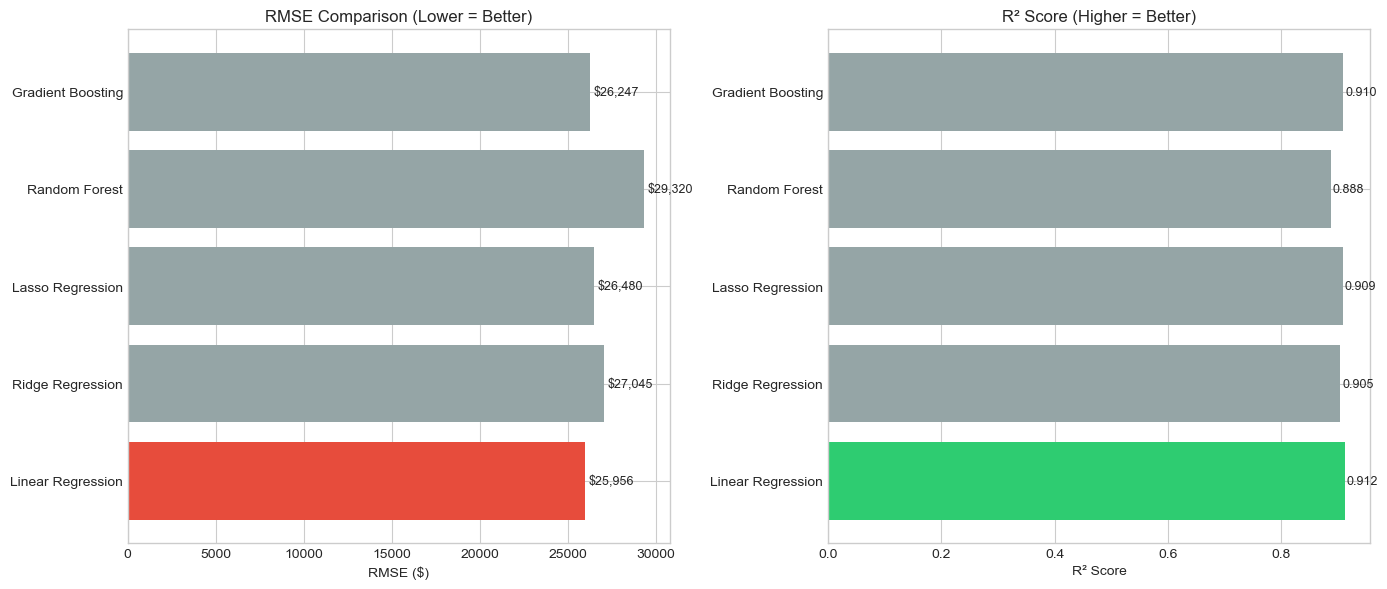


Best Model: Linear Regression
   RMSE: $25,956
   R²:   0.9122


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
names = list(results.keys())
rmse_vals = [results[n]['RMSE'] for n in names]
r2_vals   = [results[n]['R2']   for n in names]

colors = ['#e74c3c' if v == min(rmse_vals) else '#95a5a6' for v in rmse_vals]
bars = axes[0].barh(names, rmse_vals, color=colors)
axes[0].set_title('RMSE Comparison (Lower = Better)')
axes[0].set_xlabel('RMSE ($)')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(val + 200, bar.get_y()+bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)

colors2 = ['#2ecc71' if v == max(r2_vals) else '#95a5a6' for v in r2_vals]
bars2 = axes[1].barh(names, r2_vals, color=colors2)
axes[1].set_title('R² Score (Higher = Better)')
axes[1].set_xlabel('R² Score')
for bar, val in zip(bars2, r2_vals):
    axes[1].text(val + 0.003, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

best_model_name = min(results, key=lambda k: results[k]['RMSE'])
print(f"\nBest Model: {best_model_name}")
print(f"   RMSE: ${results[best_model_name]['RMSE']:,.0f}")
print(f"   R²:   {results[best_model_name]['R2']:.4f}")


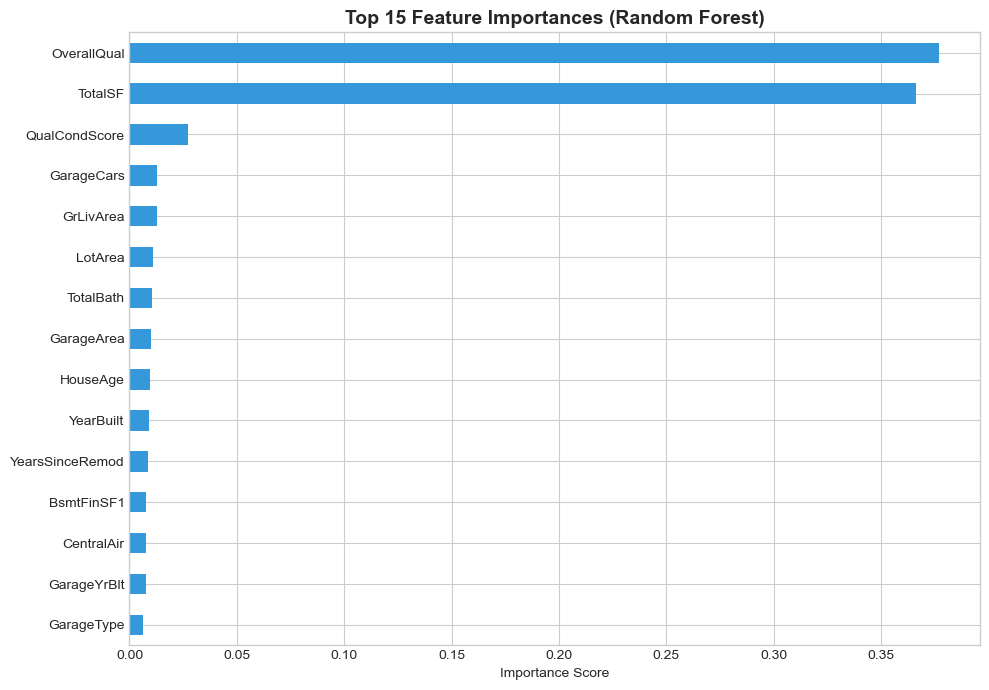

Top 5 most important features:
  GarageType          : 0.0065
  GarageYrBlt         : 0.0075
  CentralAir          : 0.0077
  BsmtFinSF1          : 0.0079
  YearsSinceRemod     : 0.0085


In [15]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 7))
top15.sort_values().plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for feat, imp in top15.tail(5)[::-1].items():
    print(f"  {feat:20s}: {imp:.4f}")


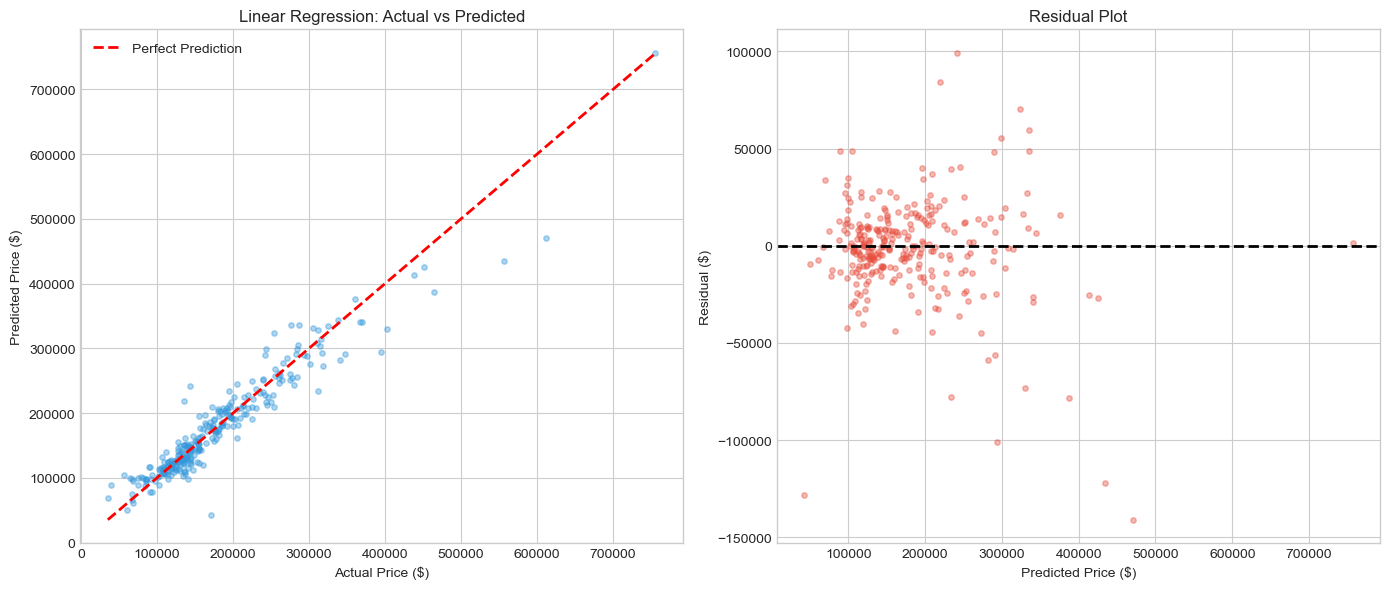

In [16]:
best = results[best_model_name]
actual = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(actual, best['preds'], alpha=0.4, color='#3498db', s=15)
lims = [min(actual.min(), best['preds'].min()), max(actual.max(), best['preds'].max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].legend()

residuals = best['preds'] - actual
axes[1].scatter(best['preds'], residuals, alpha=0.4, color='#e74c3c', s=15)
axes[1].axhline(0, color='black', lw=2, linestyle='--')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()
